# 4 · Real data: ingest, discover, quantify uncertainty

Arbitrary files go through `eqdisc.ingest`. It infers time, space, fields, trajectories, boundary conditions and sampling problems,
and writes a **data card** of assumptions that the agent (or you) can override. Here we use the real files shipped with the
workshop repos and bundled in `examples/data/`: Kuramoto–Sivashinsky (`KS_data.mat`) and KdV (`kdv_data.mat`).
There is no hidden ground truth, so models are judged with **ensembles, cross-validation and noise-floor tests**.

In [1]:
import os, sys, json, warnings
warnings.filterwarnings("ignore")
ROOT = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
os.chdir(ROOT); sys.path.insert(0, ROOT)
import numpy as np, matplotlib.pyplot as plt, pandas as pd
from IPython.display import display, Markdown, Math
import sympy as sp
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
from eqdisc import toolbox as tb, coordinates as co, plots, solvers
from eqdisc.evaluate import evaluate, load
from eqdisc.datagen import generate, add_noise, simulate, NOISE_TYPES
from eqdisc.systems import SYSTEMS

def show_eqs(rhs, title=None):
    """Pretty-print a model {var: expr} as LaTeX."""
    if title: display(Markdown(f"**{title}**"))
    for v, e in rhs.items():
        names = list(rhs) + ["t", "x"] + [f"{v}_{'x'*k}" for k in range(1, 5)]
        expr = solvers.parse(e, names) if isinstance(e, str) else e
        expr = expr.xreplace({a: sp.Float(float(a), 3) for a in expr.atoms(sp.Float)})
        display(Math(rf"\dot{{{sp.latex(sp.Symbol(v))}}} = {sp.latex(expr)}"))

def scorecard(dataset, rhs, label=""):
    r = evaluate(dataset, {"rhs": rhs}, reveal=True)
    return {"model": label, "score": round(r["score"], 2), "vf_nrmse": f"{r['vf_nrmse']:.2e}",
            "rollout_nrmse": f"{r['rollout_nrmse']:.2e}", "terms": r["n_terms"], "F1": round(r["f1"], 2),
            "coef_err": None if r["coef_rel_err"] is None else round(r["coef_rel_err"], 3)}

from IPython.display import Image
from eqdisc.ingest import ingest
from eqdisc import uq

## 4.1 Ingest the Kuramoto–Sivashinsky file

In [2]:
ks_dir, card = ingest("examples/data/KS_data.mat", name="real_ks", hints={"rename": "uu:u"})
print(card["summary"])
pd.DataFrame(card["assumptions"])[["what", "value", "confidence", "why"]]

PDE dataset 'real_ks': variables ['u'], U shape [1, 251, 1024, 1] (n_traj, nt, nx, n_fields), dt=0.4, boundary=periodic, grid={'x': {'n': 1024, 'L': 100.531, 'dx': 0.0981748, 'x0': 0.0981748}}. 6 assumptions (0 not high-confidence), 0 warnings.


,what,value,confidence,why
0,time array,tt,high,monotone 1-D array with a time-like name
1,field array(s),[uu],high,"largest >=2-D non-derivative array(s), shape [..."
2,axis layout,"[x, t]",high,every axis matched a coordinate array by length
3,boundary (x),periodic,high,wrapping last->first sample is as smooth as th...
4,x origin,0.098175,high,data.npz['x'] keeps the original coordinates; ...
5,validation split,last 25% of time,high,single trajectory: toolkit holds out the last ...


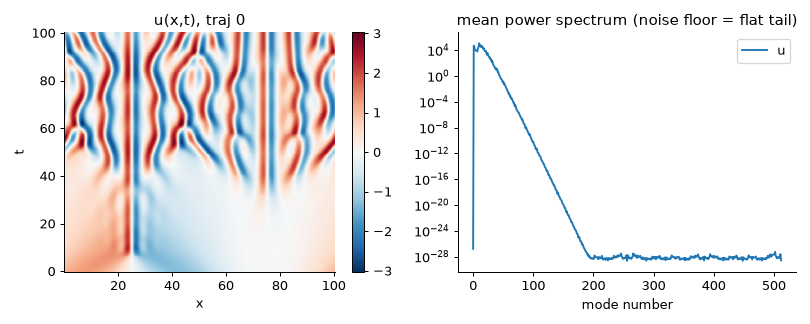

In [3]:
m, D = load(ks_dir)
plots.plot_data(m, D, "/tmp/_ks.png"); display(Image("/tmp/_ks.png"))

## 4.2 Discover, with ensemble uncertainty

In [4]:
r = tb.run_sindy(m, D, poly_degree=2, max_deriv=4)
show_eqs(r["rhs"], "SINDy on real KS data")
ens = uq.ensemble_sindy(m, D, poly_degree=2, max_deriv=4, n_models=40)
rows = [{"term": k, "inclusion": v[0], "median coef": v[1], "90% CI": f"[{v[2]}, {v[3]}]"}
        for k, v in sorted(ens["terms"]["u"].items(), key=lambda kv: -kv[1][0])[:10]]
display(pd.DataFrame(rows))
show_eqs(ens["consensus_rhs"], "consensus (inclusion ≥ 0.6)")

**SINDy on real KS data**

<IPython.core.display.Math object>

,term,inclusion,median coef,90% CI
0,u_xx,1.0,-1.0030,"[-1.006, -0.9988]"
1,u_xxxx,1.0,-1.0030,"[-1.007, -0.9996]"
2,u*u_x,1.0,-0.9972,"[-1.001, -0.9933]"


**consensus (inclusion ≥ 0.6)**

<IPython.core.display.Math object>

In [5]:
cmp = uq.compare_models(m, D, {"SINDy": r["rhs"], "consensus": ens["consensus_rhs"],
                              "textbook KS": {"u": "-u*u_x - u_xx - u_xxxx"}})
print(cmp["verdict"])
pd.DataFrame(cmp["ranking"])

Lowest CV derivative error: textbook KS (0.075, 3 terms). Indistinguishable from it: SINDy (+0.0%, z=0.2), consensus (+0.0%, z=0.2). Prefer textbook KS. Rollout valid frac 1.00 (best 1.00). Its error is 28.0x the noise floor (0.00268): systematic error remains (missing/wrong terms, or differentiation bias / correlated noise).


,0
0,textbook KS
1,SINDy
2,consensus


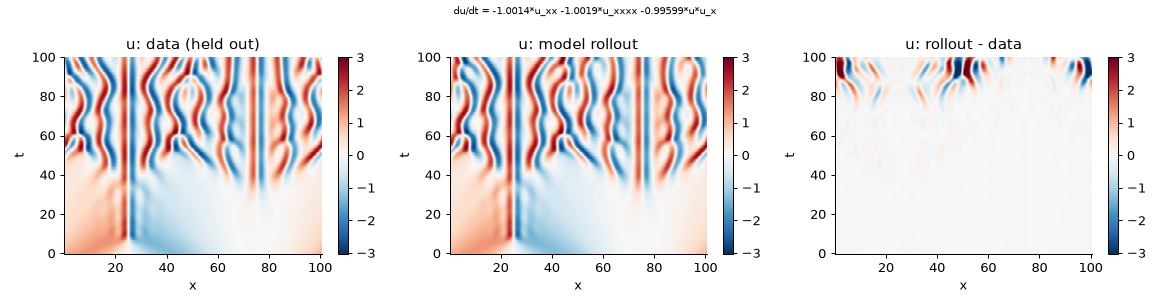

In [6]:
plots.plot_model(m, D, ens["consensus_rhs"], "/tmp/_ksm.png"); display(Image("/tmp/_ksm.png"))

## 4.3 KdV workshop file
The ingester notices the file's convention, u_t = −u u_x − u_xxx (not −6 u u_x). It also flags that the x-grid and the precomputed derivative tables disagree on the domain length.

In [7]:
kdv_dir, card = ingest("examples/data/kdv_data.mat", name="real_kdv")
for w in card.get("warnings", [])[:6]: print("•", w)
mk, Dk = load(kdv_dir)
rk = tb.run_sindy(mk, Dk, poly_degree=1, max_deriv=3)
show_eqs(rk["rhs"], "SINDy on kdv_data.mat")
cu = uq.coefficient_uncertainty(mk, Dk, rk["rhs"])
pd.DataFrame([{"term": t, **{k: v[k] for k in ("fit", "ci90", "sig")}} for t, v in cu["coefs"]["u"].items()])

• precomputed x-derivatives are consistent with domain length L=2, not the L=2.005 implied by the x array (n*dx). The file's x array and its derivatives disagree; if the tables are trusted, re-ingest with hint L=2 (rescales derivative coefficients by up to 0.75% for 3rd order)


**SINDy on kdv_data.mat**

<IPython.core.display.Math object>

,term,fit,ci90,sig
0,u_xx,0.269700,"[0.07375, 0.3541]",True
1,u_xxx,-0.977800,"[-0.9995, -0.96]",True
2,u_x,-23.130000,"[-26.59, 0.005206]",False
3,u*u_x,-1.023000,"[-1.057, -0.9814]",True
4,u*u_xxx,-0.000024,"[-2.92e-05, -4.117e-06]",True
